
📊 CHARGEMENT DES DONNÉES
✅ Données chargées: (2810, 112)
✅ Features sélectionnées: 50
✅ Classes: ['Poor' 'Excellent' 'Good' 'Critical' 'Fair']

📊 PRÉPARATION DES DONNÉES
✅ Train set: (2248, 50)
✅ Test set: (562, 50)

📊 Distribution des classes:
  Classe 0: Train 46.3%, Test 46.3%
  Classe 1: Train 7.2%, Test 7.1%
  Classe 2: Train 11.6%, Test 11.6%
  Classe 3: Train 6.3%, Test 6.4%
  Classe 4: Train 28.7%, Test 28.6%

📊 RÉÉQUILIBRAGE DES CLASSES (SMOTE)


  File "c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                

✅ Données après SMOTE: (5200, 50)
📊 Distribution après rééquilibrage:
  Classe 0: 1040 échantillons (20.0%)
  Classe 1: 1040 échantillons (20.0%)
  Classe 2: 1040 échantillons (20.0%)
  Classe 3: 1040 échantillons (20.0%)
  Classe 4: 1040 échantillons (20.0%)

📊 CONFIGURATION DES MODÈLES
✅ 14 modèles configurés

📊 ENTRAÎNEMENT DES MODÈLES

🔄 Entraînement de RandomForest...
  ✅ Accuracy (test): 0.9306
  ✅ F1-Score: 0.9115
  ⚠️  Overfitting score: 0.0560

🔄 Entraînement de XGBoost...
  ✅ Accuracy (test): 0.9413
  ✅ F1-Score: 0.9162
  ⚠️  Overfitting score: 0.0587

🔄 Entraînement de LightGBM...
  ✅ Accuracy (test): 0.9520
  ✅ F1-Score: 0.9339
  ⚠️  Overfitting score: 0.0480

🔄 Entraînement de CatBoost...
  ✅ Accuracy (test): 0.9413
  ✅ F1-Score: 0.9229
  ⚠️  Overfitting score: 0.0552

🔄 Entraînement de GradientBoosting...
  ✅ Accuracy (test): 0.9484
  ✅ F1-Score: 0.9310
  ⚠️  Overfitting score: 0.0516

🔄 Entraînement de ExtraTrees...
  ✅ Accuracy (test): 0.9217
  ✅ F1-Score: 0.9032
  ⚠️  

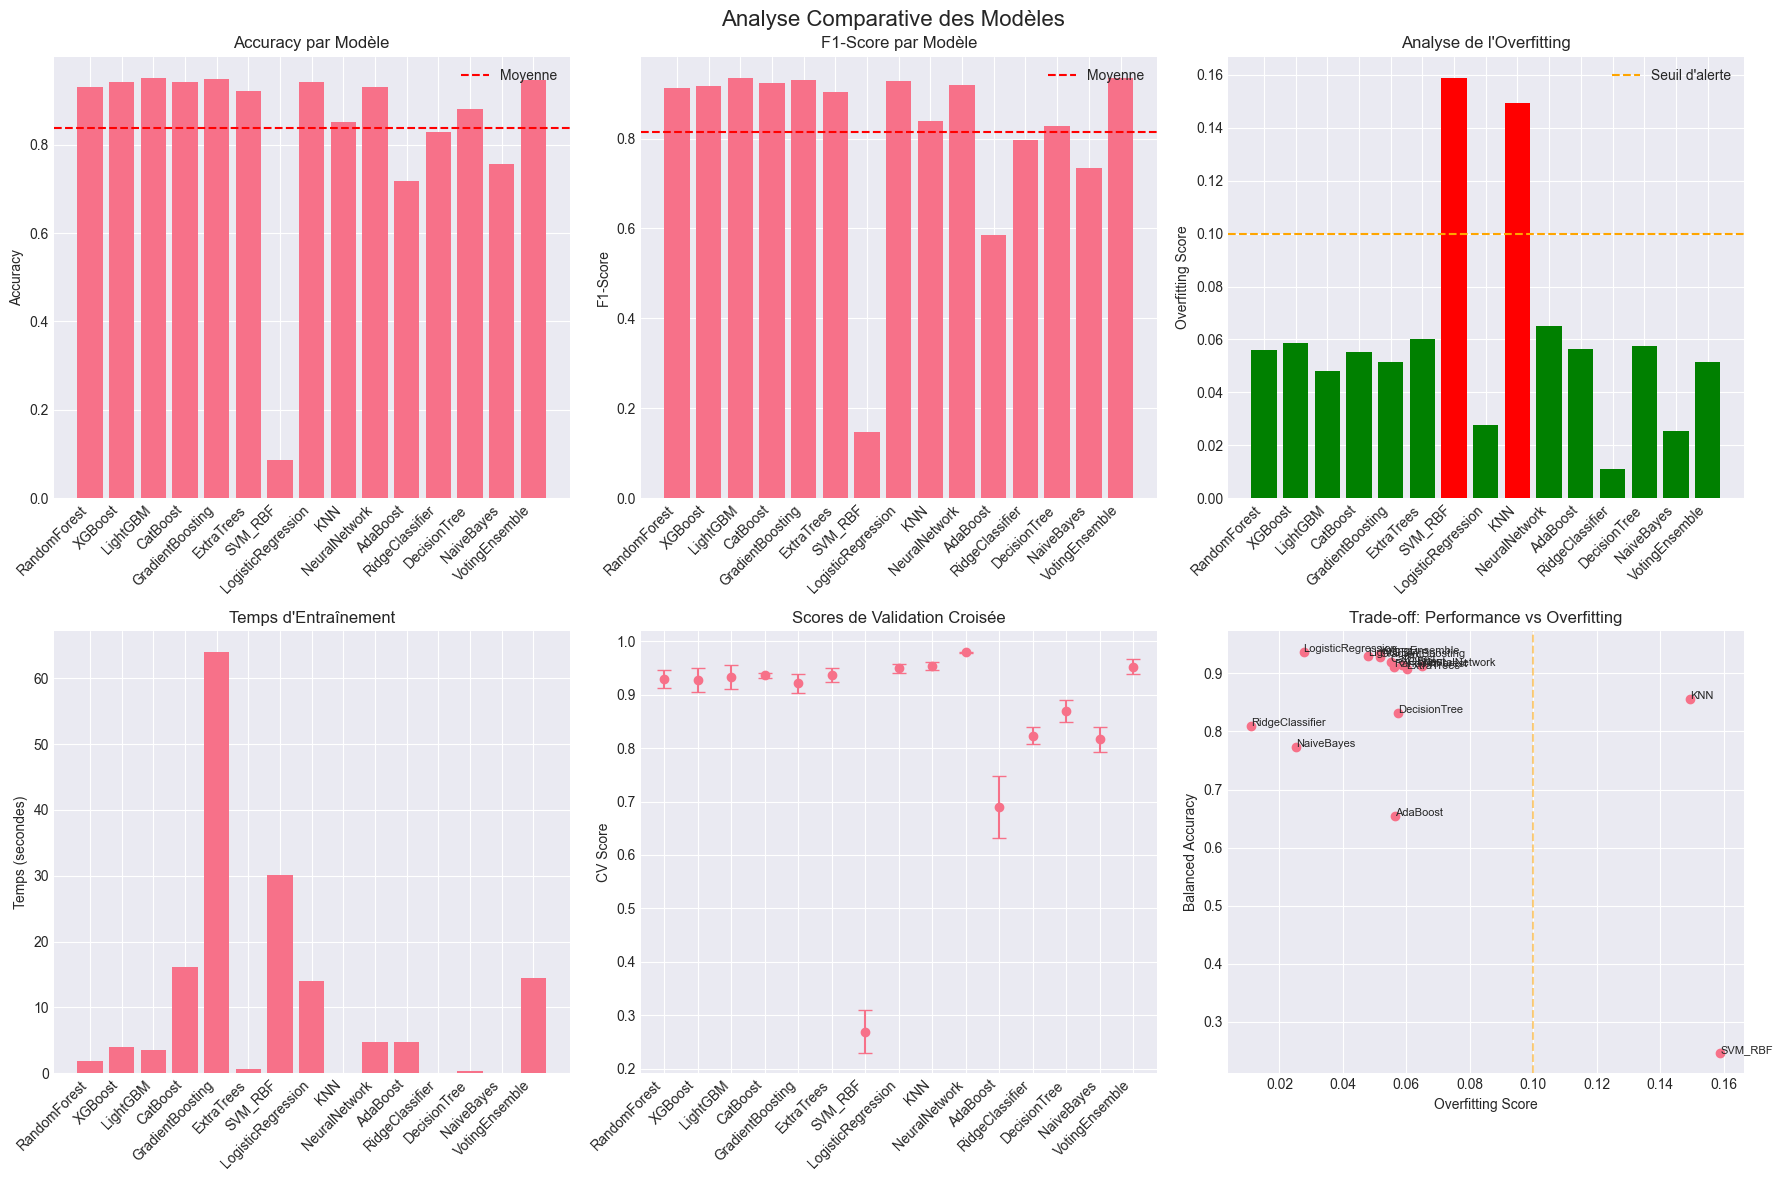

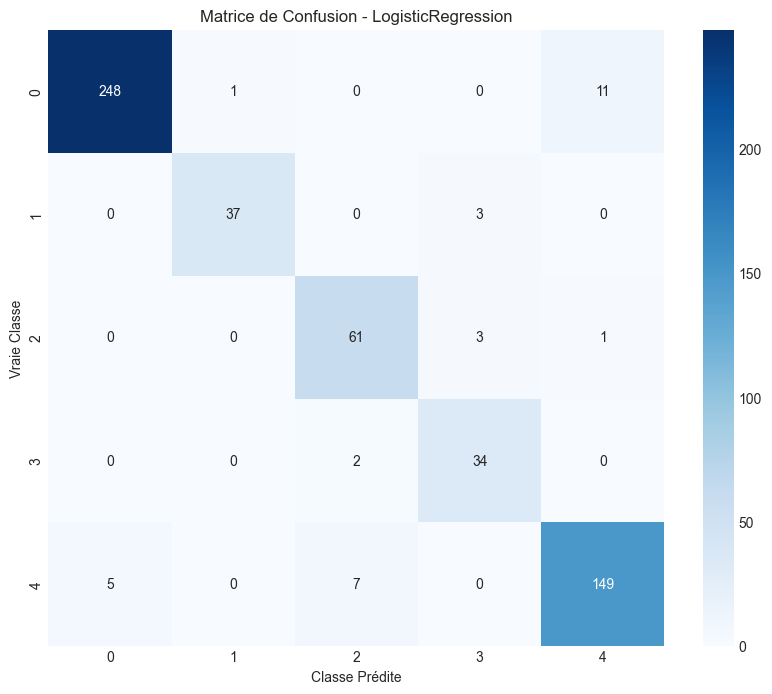

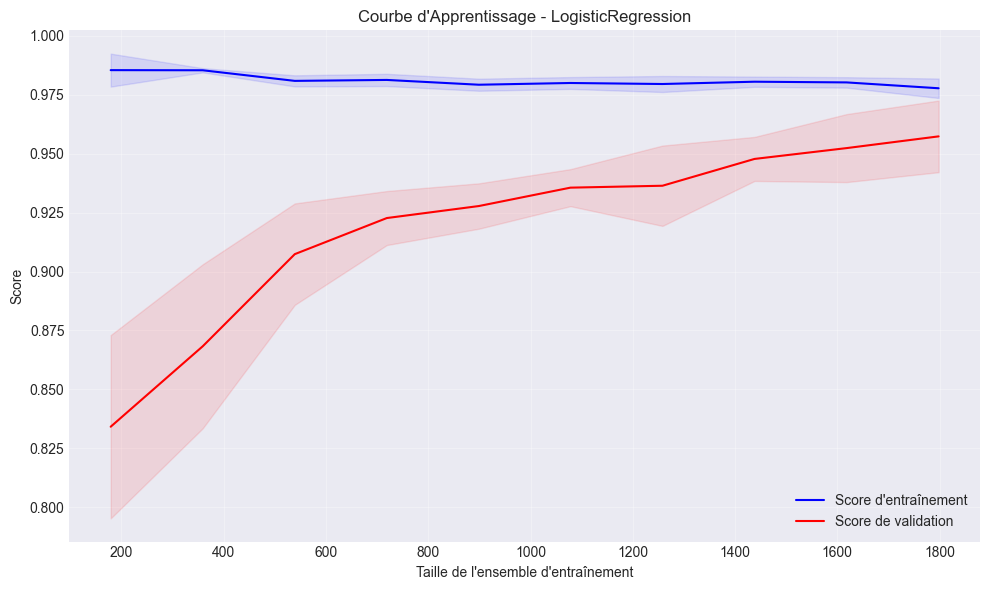


📊 SAUVEGARDE DES MODÈLES ET MÉTADONNÉES
✅ RandomForest sauvegardé dans saved_models/RandomForest_model.pkl
✅ XGBoost sauvegardé dans saved_models/XGBoost_model.pkl
✅ LightGBM sauvegardé dans saved_models/LightGBM_model.pkl
✅ CatBoost sauvegardé dans saved_models/CatBoost_model.pkl
✅ GradientBoosting sauvegardé dans saved_models/GradientBoosting_model.pkl
✅ ExtraTrees sauvegardé dans saved_models/ExtraTrees_model.pkl
✅ SVM_RBF sauvegardé dans saved_models/SVM_RBF_model.pkl
✅ LogisticRegression sauvegardé dans saved_models/LogisticRegression_model.pkl
✅ KNN sauvegardé dans saved_models/KNN_model.pkl
✅ NeuralNetwork sauvegardé dans saved_models/NeuralNetwork_model.pkl
✅ AdaBoost sauvegardé dans saved_models/AdaBoost_model.pkl
✅ RidgeClassifier sauvegardé dans saved_models/RidgeClassifier_model.pkl
✅ DecisionTree sauvegardé dans saved_models/DecisionTree_model.pkl
✅ NaiveBayes sauvegardé dans saved_models/NaiveBayes_model.pkl
✅ VotingEnsemble sauvegardé dans saved_models/VotingEnsemble_mo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, 
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    balanced_accuracy_score, cohen_kappa_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import pickle
import json
import warnings
import time
from datetime import datetime
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

# =====================================
# FONCTIONS UTILITAIRES
# =====================================

def print_section(title):
    """Affiche un titre de section formaté"""
    print("\n" + "="*80)
    print(f"📊 {title}")
    print("="*80)

def evaluate_model(model, X_train, X_test, y_train, y_test, cv_folds=5):
    # Entraînement
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Prédictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Probabilités pour AUC (si disponible)
    try:
        y_proba_test = model.predict_proba(X_test)
        auc_score = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='macro')
    except:
        auc_score = None
    
    # Métriques sur l'ensemble de test
    metrics = {
        'accuracy_train': accuracy_score(y_train, y_pred_train),
        'accuracy_test': accuracy_score(y_test, y_pred_test),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test, average='macro'),
        'recall': recall_score(y_test, y_pred_test, average='macro'),
        'f1_score': f1_score(y_test, y_pred_test, average='macro'),
        'cohen_kappa': cohen_kappa_score(y_test, y_pred_test),
        'auc_roc': auc_score,
        'training_time': training_time,
        'overfitting_score': accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test)
    }
    
    # Validation croisée
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    metrics['cv_mean'] = cv_scores.mean()
    metrics['cv_std'] = cv_scores.std()
    
    # Matrice de confusion
    metrics['confusion_matrix'] = confusion_matrix(y_test, y_pred_test).tolist()
    
    return metrics, model

def plot_learning_curve(model, X, y, title="Learning Curve"):
    """
    Trace la courbe d'apprentissage pour détecter l'overfitting
    """
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='balanced_accuracy'
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'b-', label='Score d\'entraînement')
    plt.plot(train_sizes, np.mean(val_scores, axis=1), 'r-', label='Score de validation')
    plt.fill_between(train_sizes, 
                     np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                     np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), 
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes, 
                     np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                     np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), 
                     alpha=0.1, color='red')
    plt.xlabel('Taille de l\'ensemble d\'entraînement')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return plt

# =====================================
# CHARGEMENT DES DONNÉES
# =====================================
print_section("CHARGEMENT DES DONNÉES")

# Charger les données préprocessées
df = pd.read_csv('forest_data_preprocessed.csv')
print(f"✅ Données chargées: {df.shape}")

# Identifier les colonnes
target_column = 'target_encoded'
feature_cols = [col for col in df.columns 
               if col not in ['health_class_detailed', 'target_encoded', 'system:index', '.geo']
               and df[col].dtype in ['int64', 'float64']]

# Sélectionner les top 50 features (basé sur le script précédent)
# En pratique, vous devriez charger les features sélectionnées du preprocessing
X = df[feature_cols].iloc[:, :50]  # Top 50 features
y = df[target_column]

print(f"✅ Features sélectionnées: {X.shape[1]}")
print(f"✅ Classes: {df['health_class_detailed'].unique()}")

# =====================================
# SPLIT TRAIN/TEST
# =====================================
print_section("PRÉPARATION DES DONNÉES")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")

# Distribution des classes
print("\n📊 Distribution des classes:")
for i in range(len(y.unique())):
    train_pct = (y_train == i).sum() / len(y_train) * 100
    test_pct = (y_test == i).sum() / len(y_test) * 100
    print(f"  Classe {i}: Train {train_pct:.1f}%, Test {test_pct:.1f}%")

# =====================================
# GESTION DU DÉSÉQUILIBRE DES CLASSES
# =====================================
print_section("RÉÉQUILIBRAGE DES CLASSES (SMOTE)")

# Appliquer SMOTE pour équilibrer les classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"✅ Données après SMOTE: {X_train_balanced.shape}")
print("📊 Distribution après rééquilibrage:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u}: {c} échantillons ({c/len(y_train_balanced)*100:.1f}%)")

# =====================================
# DÉFINITION DES MODÈLES
# =====================================
print_section("CONFIGURATION DES MODÈLES")

models = {
    # 1. Random Forest avec régularisation
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=20,  # Limiter la profondeur contre l'overfitting
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    # 2. XGBoost avec early stopping
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,  # Régularisation L1
        reg_lambda=1,   # Régularisation L2
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ),
    
    # 3. LightGBM avec régularisation
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
    
    # 4. CatBoost avec régularisation automatique
    'CatBoost': CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        l2_leaf_reg=3,
        random_state=42,
        verbose=False
    ),
    
    # 5. Gradient Boosting avec régularisation
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    
    # 6. Extra Trees
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    # 7. SVM avec noyau RBF
    'SVM_RBF': SVC(
        kernel='rbf',
        C=1.0,  # Paramètre de régularisation
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),
    
    # 8. Logistic Regression avec régularisation L2
    'LogisticRegression': LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    
    # 9. K-Nearest Neighbors
    'KNN': KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='minkowski',
        n_jobs=-1
    ),
    
    # 10. Neural Network avec dropout
    'NeuralNetwork': MLPClassifier(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        alpha=0.01,  # Régularisation L2
        learning_rate='adaptive',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42
    ),
    
    # 11. AdaBoost
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=1.0,
        algorithm='SAMME',
        random_state=42
    ),
    
    # 12. Ridge Classifier
    'RidgeClassifier': RidgeClassifier(
        alpha=1.0,
        class_weight='balanced',
        random_state=42
    ),
    
    # 13. Decision Tree avec élagage
    'DecisionTree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ),
    
    # 14. Naive Bayes
    'NaiveBayes': GaussianNB()
}

print(f"✅ {len(models)} modèles configurés")

# =====================================
# ENTRAÎNEMENT DES MODÈLES
# =====================================
print_section("ENTRAÎNEMENT DES MODÈLES")

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n🔄 Entraînement de {name}...")
    
    try:
        # Utiliser les données équilibrées pour certains modèles
        if name in ['SVM_RBF', 'NeuralNetwork', 'KNN']:
            metrics, trained_model = evaluate_model(
                model, X_train_balanced, X_test, y_train_balanced, y_test
            )
        else:
            metrics, trained_model = evaluate_model(
                model, X_train, X_test, y_train, y_test
            )
        
        results[name] = metrics
        trained_models[name] = trained_model
        
        # Afficher les métriques principales
        print(f"  ✅ Accuracy (test): {metrics['accuracy_test']:.4f}")
        print(f"  ✅ F1-Score: {metrics['f1_score']:.4f}")
        print(f"  ⚠️  Overfitting score: {metrics['overfitting_score']:.4f}")
        
        # Alerte si overfitting détecté
        if metrics['overfitting_score'] > 0.1:
            print(f"  ⚠️  ATTENTION: Overfitting potentiel détecté!")
            
    except Exception as e:
        print(f"  ❌ Erreur: {str(e)}")
        continue

# =====================================
# CLASSEMENT DES MODÈLES
# =====================================
print_section("CLASSEMENT DES MODÈLES")

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

# Calculer un score composite
results_df['composite_score'] = (
    results_df['balanced_accuracy'] * 0.3 +
    results_df['f1_score'] * 0.3 +
    results_df['cv_mean'] * 0.2 +
    (1 - abs(results_df['overfitting_score'])) * 0.2
)

# Trier par score composite
results_df = results_df.sort_values('composite_score', ascending=False)

print("\n🏆 CLASSEMENT DES MODÈLES (par score composite):")
print("="*80)
for i, (model_name, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {model_name:20} | Score: {row['composite_score']:.4f} | "
          f"Accuracy: {row['accuracy_test']:.4f} | F1: {row['f1_score']:.4f} | "
          f"Overfitting: {row['overfitting_score']:.4f}")

# =====================================
# MODÈLE D'ENSEMBLE (VOTING)
# =====================================
print_section("CRÉATION D'UN MODÈLE D'ENSEMBLE")

# Sélectionner les 3 meilleurs modèles pour l'ensemble
top_3_models = results_df.head(3).index.tolist()
print(f"✅ Top 3 modèles pour l'ensemble: {top_3_models}")

ensemble_estimators = [(name, trained_models[name]) for name in top_3_models]
voting_model = VotingClassifier(
    estimators=ensemble_estimators,
    voting='soft'  # Utiliser les probabilités
)

# Entraîner et évaluer le modèle d'ensemble
print("🔄 Entraînement du modèle d'ensemble...")
ensemble_metrics, voting_model_trained = evaluate_model(
    voting_model, X_train, X_test, y_train, y_test
)

results['VotingEnsemble'] = ensemble_metrics
trained_models['VotingEnsemble'] = voting_model_trained

print(f"✅ Ensemble - Accuracy: {ensemble_metrics['accuracy_test']:.4f}")
print(f"✅ Ensemble - F1-Score: {ensemble_metrics['f1_score']:.4f}")

# =====================================
# VISUALISATIONS
# =====================================
print_section("GÉNÉRATION DES VISUALISATIONS")

# 1. Comparaison des performances
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Accuracy comparison
ax = axes[0, 0]
models_names = list(results.keys())
accuracies = [results[m]['accuracy_test'] for m in models_names]
bars = ax.bar(range(len(models_names)), accuracies)
ax.set_xticks(range(len(models_names)))
ax.set_xticklabels(models_names, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy par Modèle')
ax.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Moyenne')
ax.legend()

# F1-Score comparison
ax = axes[0, 1]
f1_scores = [results[m]['f1_score'] for m in models_names]
bars = ax.bar(range(len(models_names)), f1_scores)
ax.set_xticks(range(len(models_names)))
ax.set_xticklabels(models_names, rotation=45, ha='right')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score par Modèle')
ax.axhline(y=np.mean(f1_scores), color='r', linestyle='--', label='Moyenne')
ax.legend()

# Overfitting analysis
ax = axes[0, 2]
overfitting_scores = [results[m]['overfitting_score'] for m in models_names]
colors = ['red' if score > 0.1 else 'green' for score in overfitting_scores]
bars = ax.bar(range(len(models_names)), overfitting_scores, color=colors)
ax.set_xticks(range(len(models_names)))
ax.set_xticklabels(models_names, rotation=45, ha='right')
ax.set_ylabel('Overfitting Score')
ax.set_title('Analyse de l\'Overfitting')
ax.axhline(y=0.1, color='orange', linestyle='--', label='Seuil d\'alerte')
ax.legend()

# Training time comparison
ax = axes[1, 0]
training_times = [results[m]['training_time'] for m in models_names]
bars = ax.bar(range(len(models_names)), training_times)
ax.set_xticks(range(len(models_names)))
ax.set_xticklabels(models_names, rotation=45, ha='right')
ax.set_ylabel('Temps (secondes)')
ax.set_title('Temps d\'Entraînement')

# Cross-validation scores
ax = axes[1, 1]
cv_means = [results[m]['cv_mean'] for m in models_names]
cv_stds = [results[m]['cv_std'] for m in models_names]
ax.errorbar(range(len(models_names)), cv_means, yerr=cv_stds, fmt='o', capsize=5)
ax.set_xticks(range(len(models_names)))
ax.set_xticklabels(models_names, rotation=45, ha='right')
ax.set_ylabel('CV Score')
ax.set_title('Scores de Validation Croisée')

# Balanced accuracy vs Overfitting
ax = axes[1, 2]
balanced_accs = [results[m]['balanced_accuracy'] for m in models_names]
ax.scatter(overfitting_scores, balanced_accs)
for i, name in enumerate(models_names):
    ax.annotate(name, (overfitting_scores[i], balanced_accs[i]), fontsize=8)
ax.set_xlabel('Overfitting Score')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Trade-off: Performance vs Overfitting')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5)

plt.suptitle('Analyse Comparative des Modèles', fontsize=16)
plt.tight_layout()
plt.savefig('models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Matrice de confusion du meilleur modèle
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True)
plt.title(f'Matrice de Confusion - {best_model_name}')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.savefig(f'confusion_matrix_{best_model_name}.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Courbe d'apprentissage du meilleur modèle
plot = plot_learning_curve(best_model, X_train, y_train, 
                           title=f'Courbe d\'Apprentissage - {best_model_name}')
plot.savefig(f'learning_curve_{best_model_name}.png', dpi=300, bbox_inches='tight')
plot.show()

# =====================================
# SAUVEGARDE DES MODÈLES
# =====================================
print_section("SAUVEGARDE DES MODÈLES ET MÉTADONNÉES")

# Créer un dossier pour les modèles
import os
os.makedirs('saved_models', exist_ok=True)

# Sauvegarder chaque modèle
for name, model in trained_models.items():
    model_path = f'saved_models/{name}_model.pkl'
    joblib.dump(model, model_path)
    print(f"✅ {name} sauvegardé dans {model_path}")

# Sauvegarder les métadonnées
metadata = {
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'n_classes': len(np.unique(y)),
    'feature_names': list(X.columns),
    'class_names': list(df['health_class_detailed'].unique()),
    'models_performance': results,
    'best_model': best_model_name,
    'ensemble_models': top_3_models
}

with open('saved_models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4, default=str)
print("✅ Métadonnées sauvegardées dans saved_models/metadata.json")

# Sauvegarder le DataFrame des résultats
results_df.to_csv('saved_models/models_performance.csv')
print("✅ Performances sauvegardées dans saved_models/models_performance.csv")

# Sauvegarder le scaler (si utilisé dans le preprocessing)
scaler = RobustScaler()
scaler.fit(X_train)
joblib.dump(scaler, 'saved_models/scaler.pkl')
print("✅ Scaler sauvegardé dans saved_models/scaler.pkl")

# Sauvegarder le label encoder
label_encoder = LabelEncoder()
label_encoder.fit(df['health_class_detailed'])
joblib.dump(label_encoder, 'saved_models/label_encoder.pkl')
print("✅ Label encoder sauvegardé dans saved_models/label_encoder.pkl")

# =====================================
# RAPPORT FINAL
# =====================================
print_section("RAPPORT FINAL")

print(f"""
📊 RÉSUMÉ DE L'ENTRAÎNEMENT
{'='*50}

🏆 MEILLEUR MODÈLE: {best_model_name}
   • Accuracy: {results[best_model_name]['accuracy_test']:.4f}
   • F1-Score: {results[best_model_name]['f1_score']:.4f}
   • Balanced Accuracy: {results[best_model_name]['balanced_accuracy']:.4f}
   • Overfitting Score: {results[best_model_name]['overfitting_score']:.4f}

📈 STATISTIQUES GLOBALES:
   • Modèles entraînés: {len(trained_models)}
   • Accuracy moyenne: {np.mean(accuracies):.4f}
   • F1-Score moyen: {np.mean(f1_scores):.4f}
   • Modèles avec overfitting (>0.1): {sum(1 for s in overfitting_scores if s > 0.1)}

💾 FICHIERS SAUVEGARDÉS:
   • Modèles: saved_models/[model_name]_model.pkl
   • Métadonnées: saved_models/metadata.json
   • Performances: saved_models/models_performance.csv
   • Visualisations: *.png

🚀 PROCHAINE ÉTAPE:
   Lancer l'application Streamlit pour tester les modèles:
   $ streamlit run app_streamlit.py
""")

print("\n✅ Script terminé avec succès!")


📊 PRÉDICTION DE SÉRIES TEMPORELLES NDVI - VERSION COMBINÉE
✅ 5 fichiers trouvés

📊 CHARGEMENT DES DONNÉES
📂 Chargement des données: argan
  ✅ 500 locations, 2500 observations
📂 Chargement des données: haut
  ✅ 500 locations, 2500 observations
📂 Chargement des données: mamora
  ✅ 495 locations, 2475 observations
📂 Chargement des données: moyen
  ✅ 500 locations, 2500 observations
📂 Chargement des données: rif
  ✅ 402 locations, 2010 observations

🌍 DONNÉES COMBINÉES:
  ✅ 2397 locations totales
  ✅ 11985 observations totales
  ✅ 5 régions

📊 ENTRAÎNEMENT DES MODÈLES

🌲 Traitement de la région: argan
  📊 Train: 4 points, Test: 1 points

  📈 Modèles Statistiques:
    • ARIMA...
      ✅ RMSE: 0.0215
    • SARIMA...
      ✅ RMSE: 0.0146
    • Exponential Smoothing...
      ✅ RMSE: 0.0210
    • Prophet...


21:11:37 - cmdstanpy - INFO - Chain [1] start processing
21:11:38 - cmdstanpy - INFO - Chain [1] done processing


      ✅ RMSE: 0.0096

  🤖 Modèles Deep Learning:

  🎯 Modèles Machine Learning:

🌲 Traitement de la région: haut
  📊 Train: 4 points, Test: 1 points

  📈 Modèles Statistiques:
    • ARIMA...
      ✅ RMSE: 0.0053
    • SARIMA...
      ✅ RMSE: 0.0082
    • Exponential Smoothing...
      ✅ RMSE: 0.0009
    • Prophet...


21:11:39 - cmdstanpy - INFO - Chain [1] start processing
21:11:39 - cmdstanpy - INFO - Chain [1] done processing


      ✅ RMSE: 0.0320

  🤖 Modèles Deep Learning:

  🎯 Modèles Machine Learning:

🌲 Traitement de la région: mamora
  📊 Train: 4 points, Test: 1 points

  📈 Modèles Statistiques:
    • ARIMA...
      ✅ RMSE: 0.0144
    • SARIMA...
      ✅ RMSE: 0.0196
    • Exponential Smoothing...
      ✅ RMSE: 0.0384
    • Prophet...


...

      ✅ RMSE: 0.0151

  🤖 Modèles Deep Learning:

  🎯 Modèles Machine Learning:

🌲 Traitement de la région: COMBINED
  📊 Train: 4 points, Test: 1 points

  📈 Modèles Statistiques:
    • ARIMA...
      ✅ RMSE: 0.0067
    • SARIMA...
      ✅ RMSE: 0.0048
    • Exponential Smoothing...


21:12:19 - cmdstanpy - INFO - Chain [1] start processing


      ✅ RMSE: 0.0068
    • Prophet...


21:12:19 - cmdstanpy - INFO - Chain [1] done processing


      ✅ RMSE: 0.0031

  🤖 Modèles Deep Learning:

  🎯 Modèles Machine Learning:

📊 RAPPORT DE SYNTHÈSE

🏆 MEILLEURS MODÈLES PAR RÉGION:
  argan           → Prophet         (RMSE: 0.0096)
  haut            → ExpSmoothing    (RMSE: 0.0009)
  mamora          → ARIMA           (RMSE: 0.0144)
  moyen           → ExpSmoothing    (RMSE: 0.0007)
  rif             → SARIMA          (RMSE: 0.0038)
  COMBINED        → Prophet         (RMSE: 0.0031)

🌍 PERFORMANCE SUR DONNÉES COMBINÉES:
       Model   RMSE    MAE  R2   MAPE
     Prophet 0.0031 0.0031 NaN 1.2192
      SARIMA 0.0048 0.0048 NaN 1.9087
       ARIMA 0.0067 0.0067 NaN 2.6568
ExpSmoothing 0.0068 0.0068 NaN 2.6867

🥇 MEILLEUR MODÈLE COMBINÉ: Prophet
   RMSE: 0.0031
   R²: nan

📊 PERFORMANCE MOYENNE DES MODÈLES (TOUTES RÉGIONS):
                RMSE     MAE  R2
Model                           
SARIMA        0.0088  0.0088 NaN
ARIMA         0.0101  0.0101 NaN
ExpSmoothing  0.0146  0.0146 NaN
Prophet       0.0687  0.0687 NaN

📊 GÉNÉRATION DE

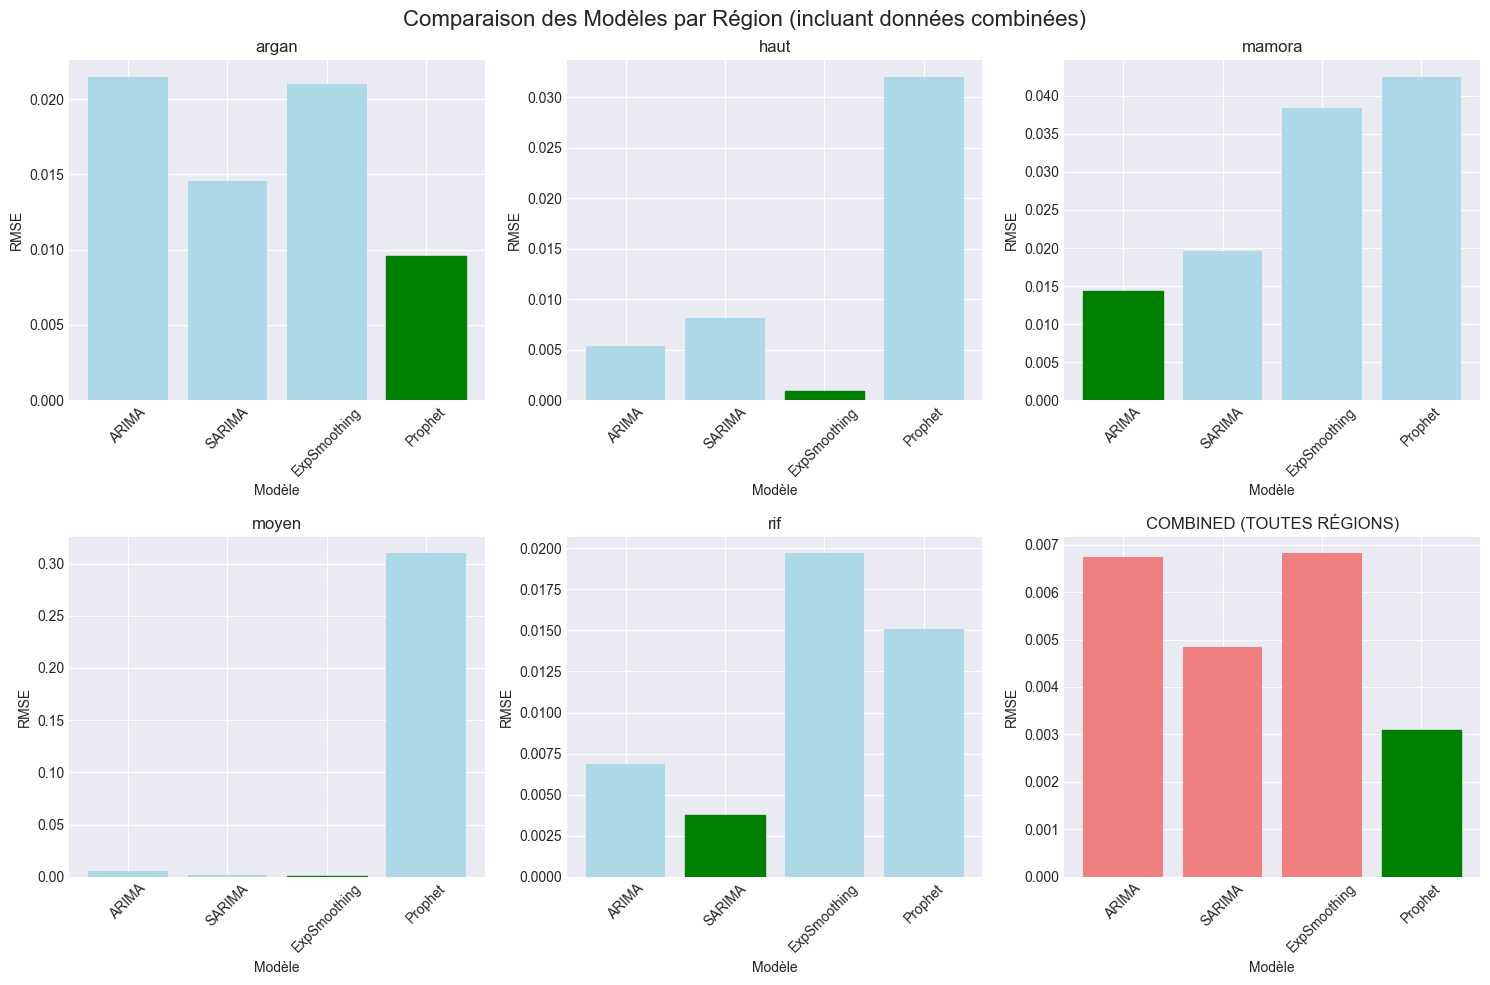

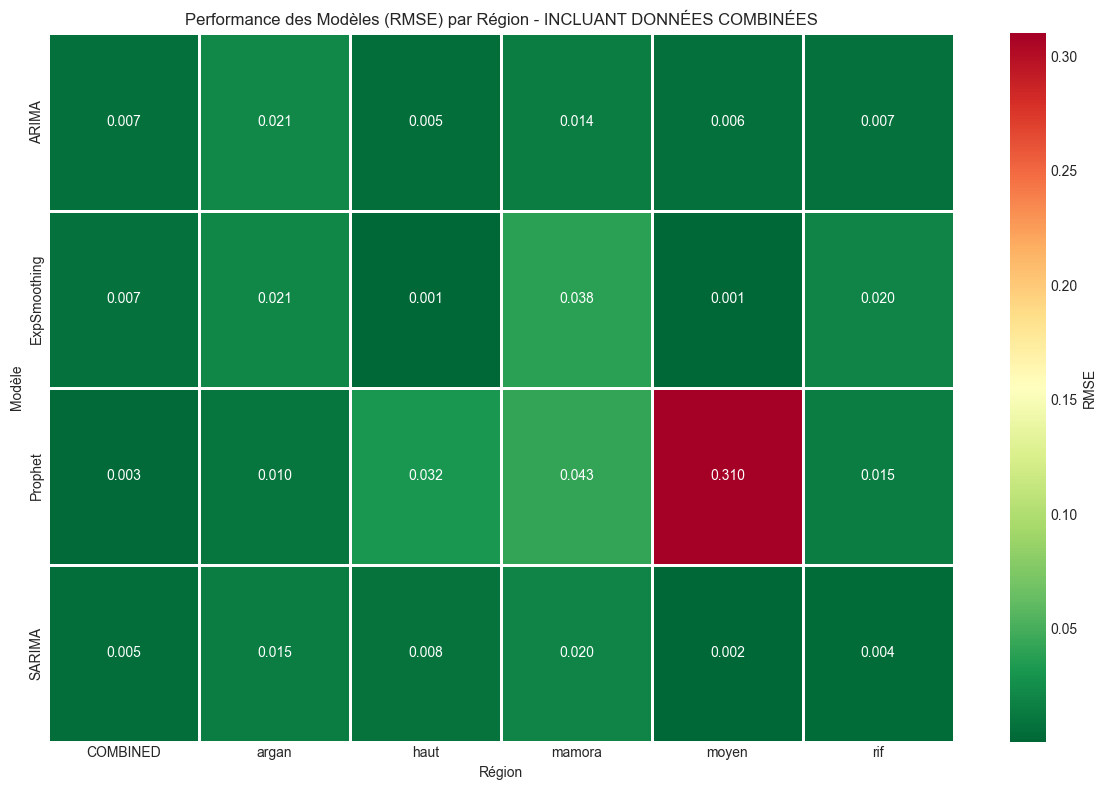

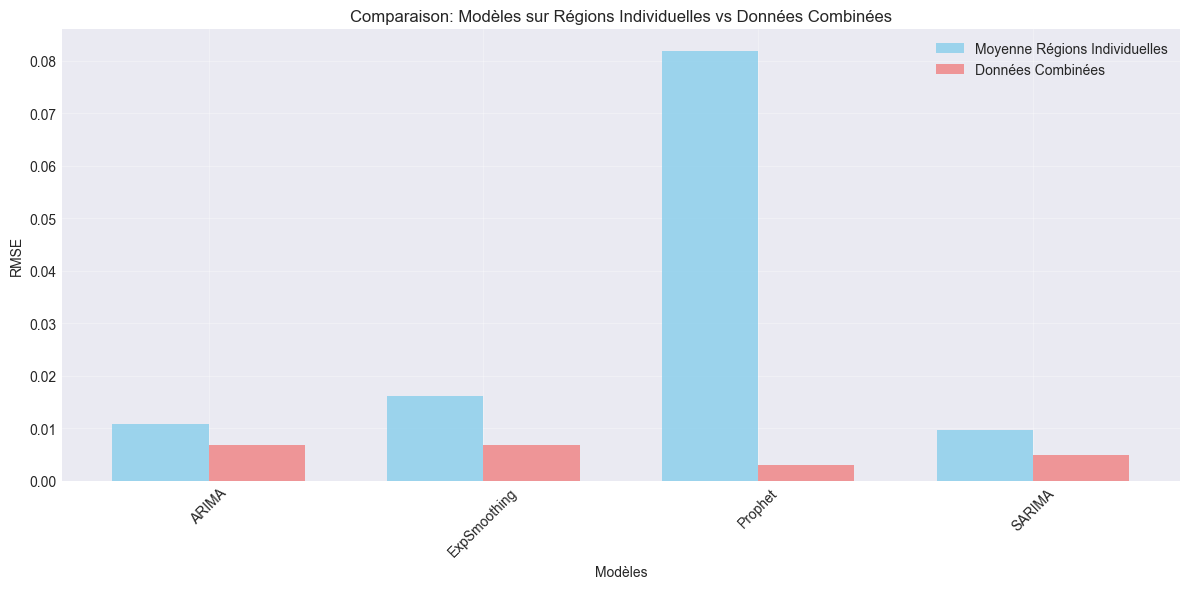

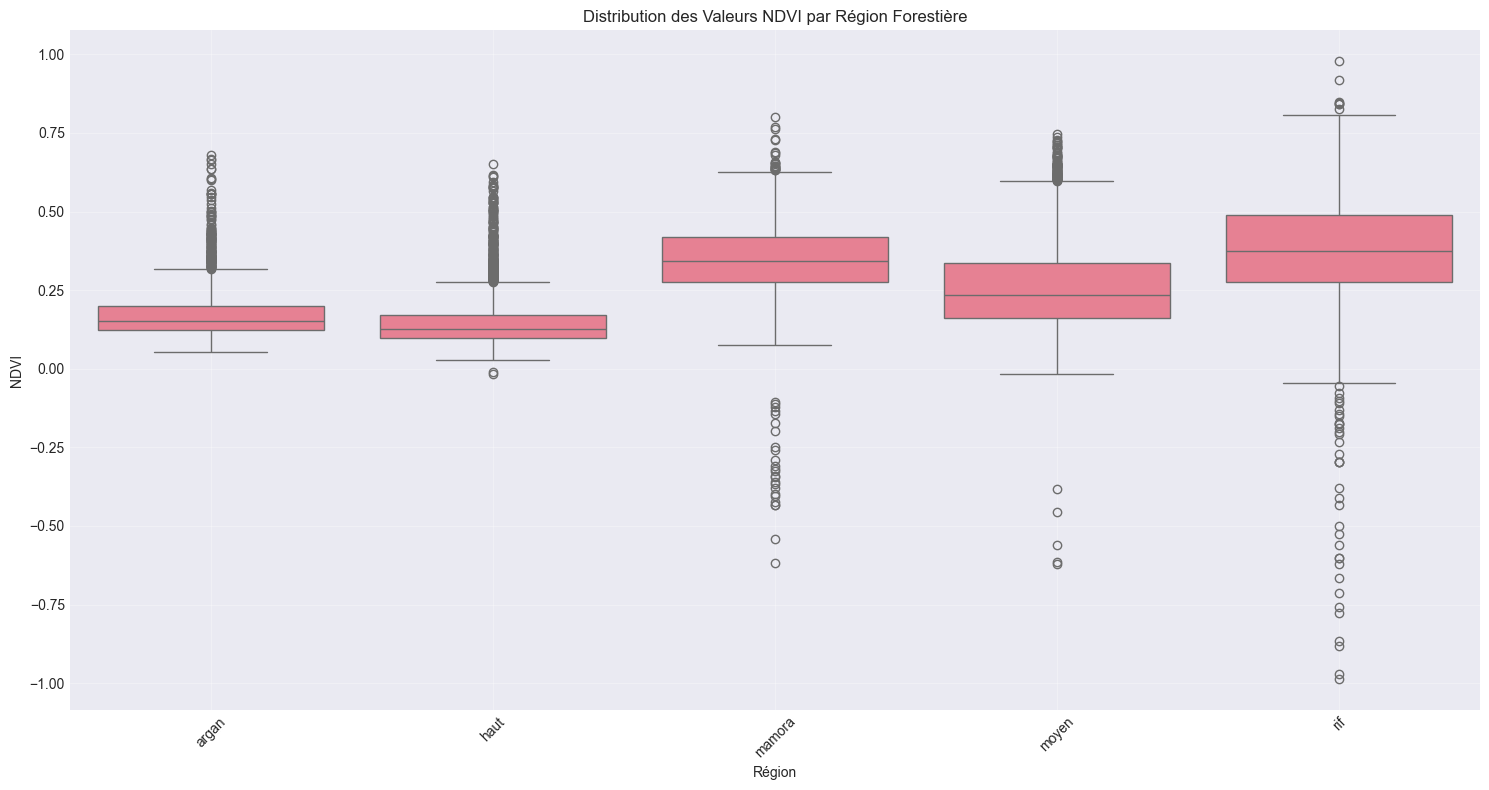


📊 SAUVEGARDE DES MODÈLES
✅ Résultats sauvegardés dans 'saved_combined_timeseries_models/results_summary_combined.csv'
✅ Résultats du modèle combiné sauvegardés séparément
✅ Modèle Prophet pour argan sauvegardé
✅ Modèle ExpSmoothing pour haut sauvegardé
✅ Modèle ARIMA pour mamora sauvegardé
✅ Modèle ExpSmoothing pour moyen sauvegardé
✅ Modèle SARIMA pour rif sauvegardé
✅ Modèle Prophet pour COMBINED sauvegardé
✅ Métadonnées sauvegardées

📊 RAPPORT DÉTAILLÉ
✅ Rapport détaillé généré: rapport_analyse.md

✅ ANALYSE COMBINÉE TERMINÉE AVEC SUCCÈS!

📊 Résumé de l'analyse:
  • Régions traitées: 5 + 1 combinée
  • Locations totales: 2397
  • Modèles testés: 4
  • Meilleur modèle global: SARIMA (RMSE moy: 0.0088)
  • Meilleur modèle combiné: Prophet

🌍 AVANTAGES DE L'APPROCHE COMBINÉE:
  • Plus de données d'entraînement
  • Modèle généralisable à toutes les régions
  • Capture des patterns inter-régionaux
  • Robustesse accrue

💾 Fichiers sauvegardés:
  • Modèles: saved_combined_timeseries_mode

In [11]:
"""
Script complet pour l'entraînement de modèles de séries temporelles NDVI
Prédiction de l'évolution du NDVI pour différentes régions forestières du Maroc
VERSION COMBINÉE - Toutes les régions ensemble
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import json
import joblib
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Modèles de séries temporelles
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
tf.random.set_seed(42)

# =====================================
# FONCTIONS UTILITAIRES
# =====================================

def print_section(title):
    """Affiche un titre de section formaté"""
    print("\n" + "="*80)
    print(f"📊 {title}")
    print("="*80)

def load_and_prepare_data(file_paths):
    """
    Charge et prépare les données de toutes les régions
    """
    all_data = {}
    combined_data = []  # Pour stocker toutes les données combinées
    
    for file_path in file_paths:
        # Extraire le nom de la région
        region_name = file_path.split('_')[2].replace('.csv', '').replace('_2024', '')
        print(f"📂 Chargement des données: {region_name}")
        
        # Charger les données
        df = pd.read_csv(file_path)
        
        # Supprimer la colonne .geo si elle existe
        if '.geo' in df.columns:
            df = df.drop(columns=['.geo'])
        
        # Transformer en format long (time series)
        ndvi_cols = [col for col in df.columns if 'NDVI_' in col]
        years = [int(col.split('_')[1]) for col in ndvi_cols]
        
        # Créer un DataFrame de séries temporelles
        time_series_data = []
        for idx, row in df.iterrows():
            for year, col in zip(years, ndvi_cols):
                time_series_data.append({
                    'location_id': f"{region_name}_{row['system:index']}",  # Préfixe avec région
                    'year': year,
                    'date': pd.Timestamp(year=year, month=7, day=1),  # Milieu de l'année
                    'NDVI': row[col],
                    'region': region_name
                })
        
        df_ts = pd.DataFrame(time_series_data)
        df_ts = df_ts.sort_values(['location_id', 'date'])
        
        # Ajouter à la base de données combinée
        combined_data.extend(time_series_data)
        
        all_data[region_name] = df_ts
        print(f"  ✅ {len(df)} locations, {len(df_ts)} observations")
    
    # Créer le DataFrame combiné
    combined_df = pd.DataFrame(combined_data)
    combined_df = combined_df.sort_values(['location_id', 'date'])
    all_data['COMBINED'] = combined_df
    
    print(f"\n🌍 DONNÉES COMBINÉES:")
    print(f"  ✅ {len(combined_df['location_id'].unique())} locations totales")
    print(f"  ✅ {len(combined_df)} observations totales")
    print(f"  ✅ {len(combined_df['region'].unique())} régions")
    
    return all_data

def create_sequences(data, n_steps_in, n_steps_out):
    """
    Crée des séquences pour les modèles de deep learning
    """
    X, y = [], []
    for i in range(len(data) - n_steps_in - n_steps_out + 1):
        X.append(data[i:i + n_steps_in])
        y.append(data[i + n_steps_in:i + n_steps_in + n_steps_out])
    return np.array(X), np.array(y)

def evaluate_predictions(y_true, y_pred, model_name="Model"):
    """
    Évalue les prédictions d'un modèle
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    metrics = {
        'model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape
    }
    
    return metrics

def plot_predictions(y_true, y_pred, dates, model_name, region):
    """
    Visualise les prédictions vs valeurs réelles
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Graphique principal
    axes[0].plot(dates, y_true, 'b-', label='Valeurs Réelles', linewidth=2)
    axes[0].plot(dates, y_pred, 'r--', label='Prédictions', linewidth=2)
    axes[0].fill_between(dates, y_true, y_pred, alpha=0.3)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('NDVI')
    axes[0].set_title(f'{model_name} - Prédictions NDVI pour {region}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Graphique des erreurs
    errors = y_true - y_pred
    axes[1].bar(dates, errors, color=['green' if e >= 0 else 'red' for e in errors], alpha=0.6)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Erreur (Réel - Prédit)')
    axes[1].set_title('Distribution des Erreurs')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# =====================================
# MODÈLES STATISTIQUES
# =====================================

def train_arima_model(train_data, test_data, order=(1,1,1)):
    """
    Entraîne un modèle ARIMA
    """
    try:
        model = ARIMA(train_data, order=order)
        model_fitted = model.fit()
        
        # Prédictions
        n_periods = len(test_data)
        predictions = model_fitted.forecast(steps=n_periods)
        
        return predictions, model_fitted
    except Exception as e:
        print(f"  ⚠️ Erreur ARIMA: {str(e)}")
        return None, None

def train_sarima_model(train_data, test_data, order=(1,1,1), seasonal_order=(1,1,1,12)):
    """
    Entraîne un modèle SARIMA (avec saisonnalité)
    """
    try:
        model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
        model_fitted = model.fit(disp=False)
        
        # Prédictions
        n_periods = len(test_data)
        predictions = model_fitted.forecast(steps=n_periods)
        
        return predictions, model_fitted
    except Exception as e:
        print(f"  ⚠️ Erreur SARIMA: {str(e)}")
        return None, None

def train_exponential_smoothing(train_data, test_data, seasonal='add', seasonal_periods=5):
    """
    Entraîne un modèle de lissage exponentiel
    """
    try:
        model = ExponentialSmoothing(
            train_data, 
            seasonal=seasonal, 
            seasonal_periods=seasonal_periods,
            trend='add'
        )
        model_fitted = model.fit()
        
        # Prédictions
        predictions = model_fitted.forecast(steps=len(test_data))
        
        return predictions, model_fitted
    except Exception as e:
        print(f"  ⚠️ Erreur Exponential Smoothing: {str(e)}")
        return None, None

def train_prophet_model(train_df, test_df):
    """
    Entraîne un modèle Prophet de Facebook
    """
    try:
        # Préparer les données pour Prophet
        train_prophet = pd.DataFrame({
            'ds': train_df.index,
            'y': train_df.values
        })
        
        # Créer et entraîner le modèle
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.05
        )
        model.fit(train_prophet)
        
        # Créer le dataframe de prédiction
        future = model.make_future_dataframe(periods=len(test_df), freq='Y')
        forecast = model.predict(future)
        
        # Extraire les prédictions pour la période de test
        predictions = forecast['yhat'].tail(len(test_df)).values
        
        return predictions, model
    except Exception as e:
        print(f"  ⚠️ Erreur Prophet: {str(e)}")
        return None, None

# =====================================
# MODÈLES DEEP LEARNING
# =====================================

def create_lstm_model(n_steps_in, n_features=1):
    """
    Crée un modèle LSTM pour la prédiction de séries temporelles
    """
    model = Sequential([
        LSTM(100, activation='relu', return_sequences=True, input_shape=(n_steps_in, n_features)),
        Dropout(0.2),
        LSTM(50, activation='relu', return_sequences=True),
        Dropout(0.2),
        LSTM(25, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def create_gru_model(n_steps_in, n_features=1):
    """
    Crée un modèle GRU pour la prédiction de séries temporelles
    """
    model = Sequential([
        GRU(100, activation='relu', return_sequences=True, input_shape=(n_steps_in, n_features)),
        Dropout(0.2),
        GRU(50, activation='relu'),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def create_cnn_lstm_model(n_steps_in, n_features=1):
    """
    Crée un modèle hybride CNN-LSTM
    """
    model = Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(n_steps_in, n_features)),
        MaxPooling1D(pool_size=2),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def train_deep_learning_model(model, X_train, y_train, X_val, y_val, epochs=100):
    """
    Entraîne un modèle de deep learning
    """
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    return model, history

# =====================================
# MODÈLES MACHINE LEARNING
# =====================================

def prepare_ml_features(data, n_lags=3):
    """
    Prépare les features pour les modèles ML (lag features)
    """
    df = pd.DataFrame(data, columns=['NDVI'])
    
    # Créer les features de lag
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['NDVI'].shift(i)
    
    # Ajouter des features statistiques roulantes
    df['rolling_mean_3'] = df['NDVI'].rolling(window=3, min_periods=1).mean()
    df['rolling_std_3'] = df['NDVI'].rolling(window=3, min_periods=1).std()
    df['rolling_min_3'] = df['NDVI'].rolling(window=3, min_periods=1).min()
    df['rolling_max_3'] = df['NDVI'].rolling(window=3, min_periods=1).max()
    
    # Supprimer les lignes avec NaN
    df = df.dropna()
    
    # Séparer features et target
    X = df.drop(columns=['NDVI'])
    y = df['NDVI']
    
    return X, y

def train_xgboost_model(X_train, y_train, X_test, y_test):
    """
    Entraîne un modèle XGBoost pour les séries temporelles
    """
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        early_stopping_rounds=10,
        verbose=False
    )
    
    predictions = model.predict(X_test)
    return predictions, model

def train_lightgbm_model(X_train, y_train, X_test, y_test):
    """
    Entraîne un modèle LightGBM pour les séries temporelles
    """
    model = lgb.LGBMRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
    )
    
    predictions = model.predict(X_test)
    return predictions, model

# =====================================
# PIPELINE PRINCIPAL
# =====================================

def train_all_models(region_data, region_name):
    """
    Entraîne tous les modèles pour une région
    """
    print(f"\n🌲 Traitement de la région: {region_name}")
    
    # Prendre la moyenne NDVI par année pour simplifier
    yearly_ndvi = region_data.groupby('year')['NDVI'].mean().reset_index()
    yearly_ndvi = yearly_ndvi.set_index('year')
    
    # Créer les dates
    dates = pd.date_range(start='2020-07-01', periods=len(yearly_ndvi), freq='Y')
    ts_data = pd.Series(yearly_ndvi['NDVI'].values, index=dates)
    
    # Split train/test (80/20)
    split_idx = int(len(ts_data) * 0.8)
    train_data = ts_data[:split_idx]
    test_data = ts_data[split_idx:]
    
    if len(train_data) < 3 or len(test_data) < 1:
        print(f"  ⚠️ Pas assez de données pour {region_name}")
        return None
    
    print(f"  📊 Train: {len(train_data)} points, Test: {len(test_data)} points")
    
    results = {}
    models = {}
    
    # ===== 1. MODÈLES STATISTIQUES =====
    print("\n  📈 Modèles Statistiques:")
    
    # ARIMA
    print("    • ARIMA...")
    predictions, model = train_arima_model(train_data.values, test_data.values, order=(1,0,1))
    if predictions is not None:
        metrics = evaluate_predictions(test_data.values, predictions, "ARIMA")
        results['ARIMA'] = metrics
        models['ARIMA'] = model
        print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
    
    # SARIMA
    print("    • SARIMA...")
    predictions, model = train_sarima_model(train_data.values, test_data.values, 
                                           order=(1,0,1), seasonal_order=(0,0,0,0))
    if predictions is not None:
        metrics = evaluate_predictions(test_data.values, predictions, "SARIMA")
        results['SARIMA'] = metrics
        models['SARIMA'] = model
        print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
    
    # Exponential Smoothing
    print("    • Exponential Smoothing...")
    if len(train_data) >= 2:
        predictions, model = train_exponential_smoothing(train_data.values, test_data.values, 
                                                        seasonal=None, seasonal_periods=None)
        if predictions is not None:
            metrics = evaluate_predictions(test_data.values, predictions, "ExpSmoothing")
            results['ExpSmoothing'] = metrics
            models['ExpSmoothing'] = model
            print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
    
    # Prophet
    print("    • Prophet...")
    predictions, model = train_prophet_model(train_data, test_data)
    if predictions is not None:
        metrics = evaluate_predictions(test_data.values, predictions, "Prophet")
        results['Prophet'] = metrics
        models['Prophet'] = model
        print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
    
    # ===== 2. MODÈLES DEEP LEARNING =====
    print("\n  🤖 Modèles Deep Learning:")
    
    # Normaliser les données
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(ts_data.values.reshape(-1, 1))
    
    # Préparer les séquences
    n_steps = min(3, len(train_data) - 1)
    if n_steps >= 2:
        X, y = create_sequences(scaled_data, n_steps, 1)
        
        if len(X) > 2:
            # Split pour DL
            train_size = int(len(X) * 0.8)
            X_train, X_test = X[:train_size], X[train_size:]
            y_train, y_test = y[:train_size], y[train_size:]
            
            # Reshape pour LSTM/GRU
            X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
            X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
            y_train = y_train.reshape(-1, 1)
            y_test = y_test.reshape(-1, 1)
            
            # LSTM
            print("    • LSTM...")
            lstm_model = create_lstm_model(n_steps)
            lstm_model, history = train_deep_learning_model(
                lstm_model, X_train, y_train, X_test, y_test, epochs=50
            )
            lstm_pred = lstm_model.predict(X_test)
            lstm_pred_original = scaler.inverse_transform(lstm_pred).flatten()
            y_test_original = scaler.inverse_transform(y_test).flatten()
            
            metrics = evaluate_predictions(y_test_original, lstm_pred_original, "LSTM")
            results['LSTM'] = metrics
            models['LSTM'] = {'model': lstm_model, 'scaler': scaler, 'n_steps': n_steps}
            print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
            
            # GRU
            print("    • GRU...")
            gru_model = create_gru_model(n_steps)
            gru_model, history = train_deep_learning_model(
                gru_model, X_train, y_train, X_test, y_test, epochs=50
            )
            gru_pred = gru_model.predict(X_test)
            gru_pred_original = scaler.inverse_transform(gru_pred).flatten()
            
            metrics = evaluate_predictions(y_test_original, gru_pred_original, "GRU")
            results['GRU'] = metrics
            models['GRU'] = {'model': gru_model, 'scaler': scaler, 'n_steps': n_steps}
            print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
    
    # ===== 3. MODÈLES MACHINE LEARNING =====
    print("\n  🎯 Modèles Machine Learning:")
    
    if len(ts_data) > 4:
        X, y = prepare_ml_features(ts_data.values, n_lags=min(3, len(ts_data)-2))
        
        if len(X) > 2:
            split_idx = int(len(X) * 0.8)
            X_train, X_test = X[:split_idx], X[split_idx:]
            y_train, y_test = y[:split_idx], y[split_idx:]
            
            # XGBoost
            print("    • XGBoost...")
            predictions, model = train_xgboost_model(X_train, y_train, X_test, y_test)
            metrics = evaluate_predictions(y_test.values, predictions, "XGBoost")
            results['XGBoost'] = metrics
            models['XGBoost'] = model
            print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
            
            # LightGBM
            print("    • LightGBM...")
            predictions, model = train_lightgbm_model(X_train, y_train, X_test, y_test)
            metrics = evaluate_predictions(y_test.values, predictions, "LightGBM")
            results['LightGBM'] = metrics
            models['LightGBM'] = model
            print(f"      ✅ RMSE: {metrics['RMSE']:.4f}")
    
    return results, models

# =====================================
# PROGRAMME PRINCIPAL
# =====================================

def main():
    print_section("PRÉDICTION DE SÉRIES TEMPORELLES NDVI - VERSION COMBINÉE")
    
    # Définir les fichiers
    file_paths = [
        'timeseries_samples_argan_2024.csv',
        'timeseries_samples_haut_atlas_2024.csv',
        'timeseries_samples_mamora_2024.csv',
        'timeseries_samples_moyen_atlas_2024.csv',
        'timeseries_samples_rif_2024.csv'
    ]
    
    # Vérifier l'existence des fichiers
    existing_files = [f for f in file_paths if os.path.exists(f)]
    
    if not existing_files:
        print("❌ Aucun fichier trouvé! Vérifiez les noms de fichiers.")
        return
    
    print(f"✅ {len(existing_files)} fichiers trouvés")
    
    # Charger et préparer les données
    print_section("CHARGEMENT DES DONNÉES")
    all_data = load_and_prepare_data(existing_files)
    
    # Entraîner les modèles pour chaque région ET pour les données combinées
    print_section("ENTRAÎNEMENT DES MODÈLES")
    
    all_results = {}
    all_models = {}
    
    # Traiter toutes les régions (individuelles + combinées)
    for region_name, region_data in all_data.items():
        results, models = train_all_models(region_data, region_name)
        if results:
            all_results[region_name] = results
            all_models[region_name] = models
    
    # Créer un rapport de synthèse
    print_section("RAPPORT DE SYNTHÈSE")
    
    # Créer un DataFrame avec tous les résultats
    summary_data = []
    for region, results in all_results.items():
        for model_name, metrics in results.items():
            summary_data.append({
                'Region': region,
                'Model': model_name,
                'RMSE': metrics['RMSE'],
                'MAE': metrics['MAE'],
                'R2': metrics['R2'],
                'MAPE': metrics['MAPE']
            })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Identifier le meilleur modèle par région
    print("\n🏆 MEILLEURS MODÈLES PAR RÉGION:")
    print("="*50)
    
    best_models = {}
    for region in summary_df['Region'].unique():
        region_df = summary_df[summary_df['Region'] == region]
        best_model = region_df.loc[region_df['RMSE'].idxmin()]
        best_models[region] = best_model['Model']
        print(f"  {region:15} → {best_model['Model']:15} (RMSE: {best_model['RMSE']:.4f})")
    
    # Focus sur les résultats combinés
    if 'COMBINED' in all_results:
        print("\n🌍 PERFORMANCE SUR DONNÉES COMBINÉES:")
        print("="*50)
        combined_results = all_results['COMBINED']
        combined_df = pd.DataFrame(list(combined_results.items()), columns=['Model', 'Metrics'])
        combined_df = pd.json_normalize(combined_df['Metrics'])
        combined_df['Model'] = list(combined_results.keys())
        combined_df = combined_df[['Model', 'RMSE', 'MAE', 'R2', 'MAPE']].round(4)
        combined_df = combined_df.sort_values('RMSE')
        print(combined_df.to_string(index=False))
        
        best_combined_model = combined_df.iloc[0]['Model']
        print(f"\n🥇 MEILLEUR MODÈLE COMBINÉ: {best_combined_model}")
        print(f"   RMSE: {combined_df.iloc[0]['RMSE']:.4f}")
        print(f"   R²: {combined_df.iloc[0]['R2']:.4f}")
    
    # Classement global des modèles
    print("\n📊 PERFORMANCE MOYENNE DES MODÈLES (TOUTES RÉGIONS):")
    print("="*60)
    
    model_avg = summary_df.groupby('Model')[['RMSE', 'MAE', 'R2']].mean().round(4)
    model_avg = model_avg.sort_values('RMSE')
    print(model_avg)
    
    # Visualisations
    print_section("GÉNÉRATION DES VISUALISATIONS")
    
    # 1. Comparaison des modèles par région (incluant COMBINED)
    regions = list(summary_df['Region'].unique())
    n_regions = len(regions)
    cols = 3
    rows = (n_regions + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten() if n_regions > 1 else [axes]
    
    for idx, region in enumerate(regions):
        if idx < len(axes):
            region_df = summary_df[summary_df['Region'] == region]
            ax = axes[idx]
            
            bars = ax.bar(region_df['Model'], region_df['RMSE'], 
                         color='lightblue' if region != 'COMBINED' else 'lightcoral')
            ax.set_xlabel('Modèle')
            ax.set_ylabel('RMSE')
            ax.set_title(f'{region}' + (' (TOUTES RÉGIONS)' if region == 'COMBINED' else ''))
            ax.tick_params(axis='x', rotation=45)
            
            # Marquer le meilleur modèle
            best_idx = region_df['RMSE'].idxmin()
            best_model_name = region_df.loc[best_idx, 'Model']
            best_rmse = region_df.loc[best_idx, 'RMSE']
            
            # Colorer le meilleur modèle en vert
            for i, (model, rmse) in enumerate(zip(region_df['Model'], region_df['RMSE'])):
                if model == best_model_name:
                    bars[i].set_color('green')
    
    # Masquer les axes non utilisés
    for idx in range(len(regions), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Comparaison des Modèles par Région (incluant données combinées)', fontsize=16)
    plt.tight_layout()
    plt.savefig('timeseries_models_comparison_combined.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Heatmap des performances
    pivot_table = summary_df.pivot(index='Model', columns='Region', values='RMSE')
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                cbar_kws={'label': 'RMSE'}, linewidths=1)
    plt.title('Performance des Modèles (RMSE) par Région - INCLUANT DONNÉES COMBINÉES')
    plt.xlabel('Région')
    plt.ylabel('Modèle')
    plt.tight_layout()
    plt.savefig('timeseries_heatmap_combined.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Comparaison spéciale: Modèles individuels vs modèle combiné
    if 'COMBINED' in all_results:
        plt.figure(figsize=(12, 6))
        
        # Performance moyenne des modèles individuels
        individual_regions = [r for r in all_results.keys() if r != 'COMBINED']
        individual_summary = summary_df[summary_df['Region'].isin(individual_regions)]
        individual_avg = individual_summary.groupby('Model')['RMSE'].mean()
        
        # Performance du modèle combiné
        combined_summary = summary_df[summary_df['Region'] == 'COMBINED']
        combined_perf = combined_summary.set_index('Model')['RMSE']
        
        # Créer le graphique de comparaison
        models = list(set(individual_avg.index) & set(combined_perf.index))
        x = range(len(models))
        width = 0.35
        
        plt.bar([i - width/2 for i in x], [individual_avg[m] for m in models], 
                width, label='Moyenne Régions Individuelles', alpha=0.8, color='skyblue')
        plt.bar([i + width/2 for i in x], [combined_perf[m] for m in models], 
                width, label='Données Combinées', alpha=0.8, color='lightcoral')
        
        plt.xlabel('Modèles')
        plt.ylabel('RMSE')
        plt.title('Comparaison: Modèles sur Régions Individuelles vs Données Combinées')
        plt.xticks(x, models, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('individual_vs_combined_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # 4. Analyse de la distribution NDVI par région
    plt.figure(figsize=(15, 8))
    
    # Créer un boxplot des valeurs NDVI par région
    all_ndvi_data = []
    for region_name, region_data in all_data.items():
        if region_name != 'COMBINED':  # Éviter la duplication
            region_ndvi = region_data['NDVI'].values
            all_ndvi_data.extend([(region_name, ndvi) for ndvi in region_ndvi])
    
    ndvi_df = pd.DataFrame(all_ndvi_data, columns=['Region', 'NDVI'])
    
    sns.boxplot(data=ndvi_df, x='Region', y='NDVI')
    plt.title('Distribution des Valeurs NDVI par Région Forestière')
    plt.xlabel('Région')
    plt.ylabel('NDVI')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('ndvi_distribution_by_region.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Sauvegarder les modèles et résultats
    print_section("SAUVEGARDE DES MODÈLES")
    
    # Créer le dossier de sauvegarde
    os.makedirs('saved_combined_timeseries_models', exist_ok=True)
    
    # Sauvegarder les résultats
    summary_df.to_csv('saved_combined_timeseries_models/results_summary_combined.csv', index=False)
    print("✅ Résultats sauvegardés dans 'saved_combined_timeseries_models/results_summary_combined.csv'")
    
    # Sauvegarder spécifiquement les résultats du modèle combiné
    if 'COMBINED' in all_results:
        combined_results_df = pd.DataFrame.from_dict(all_results['COMBINED'], orient='index')
        combined_results_df.to_csv('saved_combined_timeseries_models/combined_model_results.csv')
        print("✅ Résultats du modèle combiné sauvegardés séparément")
    
    # Sauvegarder les meilleurs modèles
    for region, models in all_models.items():
        best_model_name = best_models.get(region)
        if best_model_name and best_model_name in models:
            model = models[best_model_name]
            
            # Sauvegarder selon le type de modèle
            if best_model_name in ['LSTM', 'GRU', 'CNN-LSTM']:
                # Sauvegarder les modèles Keras
                model['model'].save(f'saved_combined_timeseries_models/{region}_{best_model_name}_model.h5')
                joblib.dump(model['scaler'], f'saved_combined_timeseries_models/{region}_{best_model_name}_scaler.pkl')
            elif best_model_name == 'Prophet':
                # Prophet nécessite pickle
                import pickle
                with open(f'saved_combined_timeseries_models/{region}_{best_model_name}_model.pkl', 'wb') as f:
                    pickle.dump(model, f)
            else:
                # Sauvegarder les autres modèles
                joblib.dump(model, f'saved_combined_timeseries_models/{region}_{best_model_name}_model.pkl')
            
            print(f"✅ Modèle {best_model_name} pour {region} sauvegardé")
    
    # Sauvegarder les métadonnées
    metadata = {
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'approach': 'Combined Regions Analysis',
        'regions': [r for r in all_data.keys() if r != 'COMBINED'],
        'combined_data_points': len(all_data.get('COMBINED', [])),
        'models_tested': list(summary_df['Model'].unique()),
        'best_models': best_models,
        'time_period': '2020-2024',
        'prediction_horizon': '1-2 years',
        'best_overall_model': model_avg.index[0],
        'best_combined_model': best_combined_model if 'COMBINED' in all_results else None,
        'total_locations': len(all_data.get('COMBINED', pd.DataFrame())['location_id'].unique()) if 'COMBINED' in all_data else 0,
        'analysis_type': 'Individual + Combined Regions'
    }
    
    with open('saved_combined_timeseries_models/metadata.json', 'w') as f:
        json.dump(metadata, f, indent=4)
    print("✅ Métadonnées sauvegardées")
    
    # Créer un rapport détaillé
    print_section("RAPPORT DÉTAILLÉ")
    
    report = f"""
# RAPPORT D'ANALYSE - MODÉLISATION NDVI COMBINÉE
## Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

### 🌍 DONNÉES ANALYSÉES
- **Régions individuelles**: {len([r for r in all_data.keys() if r != 'COMBINED'])}
- **Locations totales**: {len(all_data.get('COMBINED', pd.DataFrame())['location_id'].unique()) if 'COMBINED' in all_data else 'N/A'}
- **Observations totales**: {len(all_data.get('COMBINED', pd.DataFrame())) if 'COMBINED' in all_data else 'N/A'}
- **Période**: 2020-2024

### 🏆 MEILLEURS MODÈLES PAR RÉGION
"""
    
    for region, model_name in best_models.items():
        if region in all_results and model_name in all_results[region]:
            rmse = all_results[region][model_name]['RMSE']
            r2 = all_results[region][model_name]['R2']
            report += f"- **{region}**: {model_name} (RMSE: {rmse:.4f}, R²: {r2:.4f})\n"
    
    if 'COMBINED' in all_results:
        report += f"""
### 🌍 MODÈLE COMBINÉ (TOUTES RÉGIONS)
- **Meilleur modèle**: {best_combined_model}
- **Performance**:
"""
        best_combined_metrics = all_results['COMBINED'][best_combined_model]
        for metric, value in best_combined_metrics.items():
            if metric != 'model':
                report += f"  - {metric}: {value:.4f}\n"
    
    report += f"""
### 📊 CLASSEMENT GLOBAL DES MODÈLES
"""
    for idx, (model, row) in enumerate(model_avg.iterrows(), 1):
        report += f"{idx}. **{model}** - RMSE moyen: {row['RMSE']:.4f}\n"
    
    report += f"""
### 💡 RECOMMANDATIONS
1. **Pour une approche globale**: Utiliser le modèle {best_combined_model if 'COMBINED' in all_results else model_avg.index[0]}
2. **Pour une approche régionale**: Adapter selon la région spécifique
3. **Surveillance continue**: Réévaluer les modèles avec de nouvelles données

### 📁 FICHIERS GÉNÉRÉS
- `results_summary_combined.csv`: Résultats détaillés
- `combined_model_results.csv`: Résultats spécifiques au modèle combiné
- `*.png`: Visualisations
- `saved_combined_timeseries_models/`: Modèles entraînés
"""
    
    with open('saved_combined_timeseries_models/rapport_analyse.md', 'w', encoding='utf-8') as f:
        f.write(report)
    print("✅ Rapport détaillé généré: rapport_analyse.md")
    
    print("\n" + "="*80)
    print("✅ ANALYSE COMBINÉE TERMINÉE AVEC SUCCÈS!")
    print("="*80)
    print(f"""
📊 Résumé de l'analyse:
  • Régions traitées: {len([r for r in all_data.keys() if r != 'COMBINED'])} + 1 combinée
  • Locations totales: {len(all_data.get('COMBINED', pd.DataFrame())['location_id'].unique()) if 'COMBINED' in all_data else 'N/A'}
  • Modèles testés: {len(summary_df['Model'].unique())}
  • Meilleur modèle global: {model_avg.index[0]} (RMSE moy: {model_avg.iloc[0]['RMSE']:.4f})
  • Meilleur modèle combiné: {best_combined_model if 'COMBINED' in all_results else 'N/A'}
  
🌍 AVANTAGES DE L'APPROCHE COMBINÉE:
  • Plus de données d'entraînement
  • Modèle généralisable à toutes les régions
  • Capture des patterns inter-régionaux
  • Robustesse accrue
  
💾 Fichiers sauvegardés:
  • Modèles: saved_combined_timeseries_models/[region]_[model]_model.*
  • Résultats: saved_combined_timeseries_models/results_summary_combined.csv
  • Rapport: saved_combined_timeseries_models/rapport_analyse.md
  • Graphiques: *.png
  
🚀 Prochaines étapes:
  1. Analyser le rapport détaillé
  2. Tester les prédictions avec le modèle combiné
  3. Valider sur de nouvelles données
  4. Déployer pour la surveillance opérationnelle
    """)

if __name__ == "__main__":
    main()